# Proyecto Final de IA: Predicción del Precio de Venta de Viviendas

## Descripción del Problema

El objetivo de este proyecto es construir un modelo de **regresión supervisada** capaz de predecir el precio de venta (`SalePrice`) de viviendas residenciales en Ames, Iowa (USA), a partir de 80 variables descriptivas de cada propiedad.

Este es un problema de **aprendizaje supervisado de regresión**: conocemos el precio real de cada vivienda en el conjunto de entrenamiento, y queremos que el modelo generalice esa relación para predecir precios de viviendas nuevas.

### Dataset: Ames Housing (House Prices)
- **Origen**: OpenML / Kaggle "House Prices: Advanced Regression Techniques"
- **Tamaño**: 1.460 viviendas × 81 variables
- **Variable objetivo**: `SalePrice` (precio de venta en USD)
- **Variables predictoras**: 79 features que incluyen área habitable, calidad de construcción, año de construcción, barrio, número de habitaciones, garaje, etc.

### Estructura del Proyecto
| Ejercicio | Contenido |
|-----------|-----------|
| **Ejercicio 1** | Análisis Exploratorio (EDA) y Preprocesamiento |
| **Ejercicio 2** | Modelado con Random Forest y Evaluación |
| **Ejercicio 3** | Optimización de Hiperparámetros, Comparación de Modelos y Despliegue |

---
## EJERCICIO 1: Big Data — Preparación y Análisis

### Importación de Librerías

Importamos todas las librerías necesarias para el pipeline completo: análisis, visualización, preprocesamiento y modelado.

Aunque el dataset (~1.460 filas) no requiere herramientas de Big Data como `PySpark` o `Dask`, la arquitectura usada con `sklearn.pipeline` y `ColumnTransformer` escala bien a conjuntos de datos más grandes.

In [ ]:
# --- Librerías de manipulación y análisis de datos ---
import pandas as pd          # DataFrames y operaciones tabulares
import numpy as np           # Operaciones numéricas y álgebra lineal
from functools import reduce
import operator

# --- Librerías de visualización ---
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

# --- Utilidades ---
import time                  # Medir tiempos de entrenamiento
import joblib                # Serializar/deserializar modelos entrenados
import os

# Fix SSL para descarga del dataset desde OpenML (entornos con certificados no verificados)
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

# --- Carga del dataset ---
from sklearn.datasets import fetch_openml

# --- Preprocesamiento ---
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Modelos de regresión ---
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.ensemble import HistGradientBoostingRegressor

# --- Métricas de evaluación ---
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


### Carga del Dataset

Usamos `fetch_openml` para descargar directamente el dataset "House Prices" de OpenML. El parámetro `parser='auto'` permite que pandas infiera los tipos de columna automáticamente.

In [200]:
print("Cargando dataset 'House Prices' desde OpenML...")
housing = fetch_openml(name="house_prices", as_frame=True, version=1, parser='auto')
df = housing.frame

print(f"\nDimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Variable objetivo: 'SalePrice' (precio de venta en USD)")
print(f"\nPrimeras 5 filas del dataset:")
df.head()

Cargando dataset 'House Prices' desde OpenML...

Dimensiones del dataset: 1460 filas × 81 columnas
Variable objetivo: 'SalePrice' (precio de venta en USD)

Primeras 5 filas del dataset:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


### Análisis Exploratorio de los Datos (EDA)

El EDA nos permite entender la estructura del dataset antes de modelar. Los objetivos son:
1. Detectar valores faltantes y su magnitud
2. Entender la distribución de la variable objetivo (`SalePrice`)
3. Identificar qué variables tienen mayor correlación con el precio
4. Detectar outliers y variables con distribución sesgada

In [201]:
# --- Estadística Descriptiva ---
# describe() calcula automáticamente las medidas estadísticas básicas para variables numéricas:
# count (número de valores no nulos), mean, std, min, percentiles y max.
# Esto nos da una primera visión de escala, dispersión y posibles outliers.
print("Estadística Descriptiva (variables numéricas):")
print(df.describe().T.to_string())  # .T para leer mejor con muchas columnas

Estadística Descriptiva (variables numéricas):
                count           mean           std      min        25%       50%        75%       max
Id             1460.0     730.500000    421.610009      1.0     365.75     730.5    1095.25    1460.0
MSSubClass     1460.0      56.897260     42.300571     20.0      20.00      50.0      70.00     190.0
LotFrontage    1201.0      70.049958     24.284752     21.0      59.00      69.0      80.00     313.0
LotArea        1460.0   10516.828082   9981.264932   1300.0    7553.50    9478.5   11601.50  215245.0
OverallQual    1460.0       6.099315      1.382997      1.0       5.00       6.0       7.00      10.0
OverallCond    1460.0       5.575342      1.112799      1.0       5.00       5.0       6.00       9.0
YearBuilt      1460.0    1971.267808     30.202904   1872.0    1954.00    1973.0    2000.00    2010.0
YearRemodAdd   1460.0    1984.865753     20.645407   1950.0    1967.00    1994.0    2004.00    2010.0
MasVnrArea     1452.0     103.68526

In [202]:
# --- Análisis de Valores Faltantes (Nulos) ---

nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100)

nulos_df = (
    pd.DataFrame({
        'n_nulls': nulos,
        'pct_nulls': nulos_pct
    })
    .query('n_nulls > 0')
    .sort_values('pct_nulls', ascending=False)
)

# Resumen general
print("=" * 60)
print("RESUMEN DE VALORES FALTANTES")
print("=" * 60)
print(f"Total columnas: {df.shape[1]}")
print(f"Columnas con nulos: {nulos_df.shape[0]}")
print(f"Porcentaje columnas afectadas: {(nulos_df.shape[0] / df.shape[1]) * 100:.2f}%")

# Top columnas más problemáticas
print("\nTop 10 columnas con más nulos:")
print(nulos_df.head(10).to_string(float_format="%.2f"))

# Distribución por tipo de dato
print("\nDistribución de tipos de datos:")
print(df.dtypes.value_counts())

# Columnas críticas (>40%)
criticas = nulos_df[nulos_df['pct_nulls'] > 40]
print("\nColumnas críticas (>40% nulos):")
print(criticas.to_string(float_format="%.2f") if not criticas.empty else "Ninguna")

print("=" * 60)

RESUMEN DE VALORES FALTANTES
Total columnas: 81
Columnas con nulos: 19
Porcentaje columnas afectadas: 23.46%

Top 10 columnas con más nulos:
              n_nulls  pct_nulls
PoolQC           1453      99.52
MiscFeature      1406      96.30
Alley            1369      93.77
Fence            1179      80.75
FireplaceQu       690      47.26
LotFrontage       259      17.74
GarageType         81       5.55
GarageYrBlt        81       5.55
GarageFinish       81       5.55
GarageQual         81       5.55

Distribución de tipos de datos:
str        43
int64      35
float64     3
Name: count, dtype: int64

Columnas críticas (>40% nulos):
             n_nulls  pct_nulls
PoolQC          1453      99.52
MiscFeature     1406      96.30
Alley           1369      93.77
Fence           1179      80.75
FireplaceQu      690      47.26


In [203]:
os.makedirs('visualization', exist_ok=True)
print("Carpeta 'visualization/' lista para guardar los gráficos.")

Carpeta 'visualization/' lista para guardar los gráficos.


Top 10 variables numéricas más correlacionadas con SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101


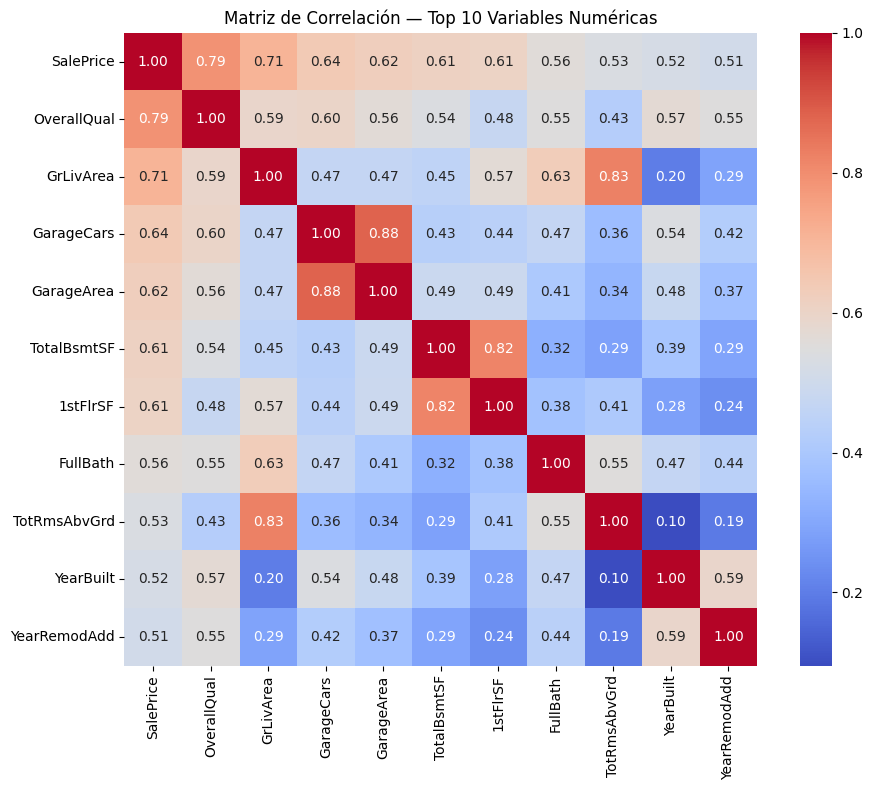

In [ ]:
# --- Análisis de Correlación con SalePrice ---
# La matriz de correlación mide la relación lineal entre dos variables (-1 a +1).
# Variables con alta correlación positiva suben junto al precio;
# con alta correlación negativa, suben cuando el precio baja.
# Solo aplica directamente a variables numéricas.
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

top_features = corr_matrix['SalePrice'].sort_values(ascending=False).head(11)  # Top 10 + propia
print("Top 10 variables numéricas más correlacionadas con SalePrice:")
print(top_features.drop('SalePrice').to_string())

# Heatmap de correlaciones entre las top features
top_corr = numeric_df[top_features.index].corr()

plt.figure(figsize=(10, 8))  # Ajusta tamaño directamente
sns.heatmap(top_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)

plt.title('Matriz de Correlación — Top 10 Variables Numéricas')

plt.tight_layout()
plt.savefig('visualization/corr_matrix.png', dpi=100)
plt.show()
plt.close()

### Interpretación:
OverallQual (r=0.79) y GrLivArea (r=0.71) dominan la predicción del precio.  
GarageCars y GarageArea están muy correlacionadas entre sí (multicolinealidad).  

---

### Distribución de la Variable Objetivo (SalePrice)
Analizar la distribución de SalePrice es clave porque:
- Si está muy sesgada (cola larga a la derecha), los modelos lineales se verán afectados.
- Un sesgo pronunciado sugiere aplicar una transformación logarítmica (log1p) para normalizarla, aunque los modelos de árbol como Random Forest son robustos ante esto.

Asimetría (Skewness) de SalePrice: 1.8829
Un valor de skewness > 1 confirma sesgo positivo (cola a la derecha).
La transformación log aplana la distribución y la acerca a una normal.


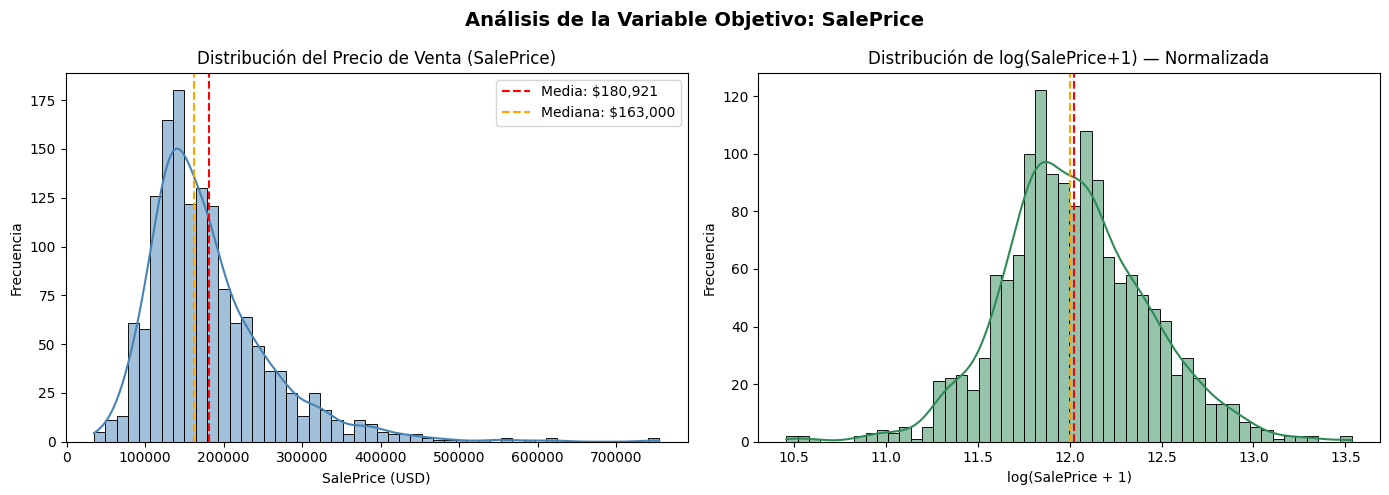

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de SalePrice original
sns.histplot(df['SalePrice'], bins=50, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución del Precio de Venta (SalePrice)')
axes[0].set_xlabel('SalePrice (USD)')
axes[0].set_ylabel('Frecuencia')
axes[0].axvline(df['SalePrice'].mean(), color='red', linestyle='--', label=f"Media: ${df['SalePrice'].mean():,.0f}")
axes[0].axvline(df['SalePrice'].median(), color='orange', linestyle='--', label=f"Mediana: ${df['SalePrice'].median():,.0f}")
axes[0].legend()

skewness = df['SalePrice'].skew()
print(f"Asimetría (Skewness) de SalePrice: {skewness:.4f}")
print("Un valor de skewness > 1 confirma sesgo positivo (cola a la derecha).")
print("La transformación log aplana la distribución y la acerca a una normal.")

if skewness > 1.0:
    # Histograma con transformación logarítmica
    normalized_df = np.log1p(df['SalePrice'])
    sns.histplot(normalized_df, bins=50, kde=True, ax=axes[1], color='seagreen')
    axes[1].set_title('Distribución de log(SalePrice+1) — Normalizada')
    axes[1].set_xlabel('log(SalePrice + 1)')
    axes[1].set_ylabel('Frecuencia')
    axes[1].axvline(normalized_df.mean(), color='red', linestyle='--', label=f"Media: ${normalized_df.mean():,.0f}")
    axes[1].axvline(normalized_df.median(), color='orange', linestyle='--', label=f"Mediana: ${normalized_df.median():,.0f}")

    plt.suptitle('Análisis de la Variable Objetivo: SalePrice', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualization/hist_saleprice.png', dpi=100)
plt.show()
plt.close()

### Diagrama de Dispersión: Área Habitable vs Precio
GrLivArea (superficie habitable sobre tierra en pies²) es la variable numérica
con mayor correlación con SalePrice después de OverallQual.
Un scatter plot nos revela:
- Si la relación es lineal o no lineal
- Si existen outliers extremos (p.ej. casas muy grandes vendidas a bajo precio)

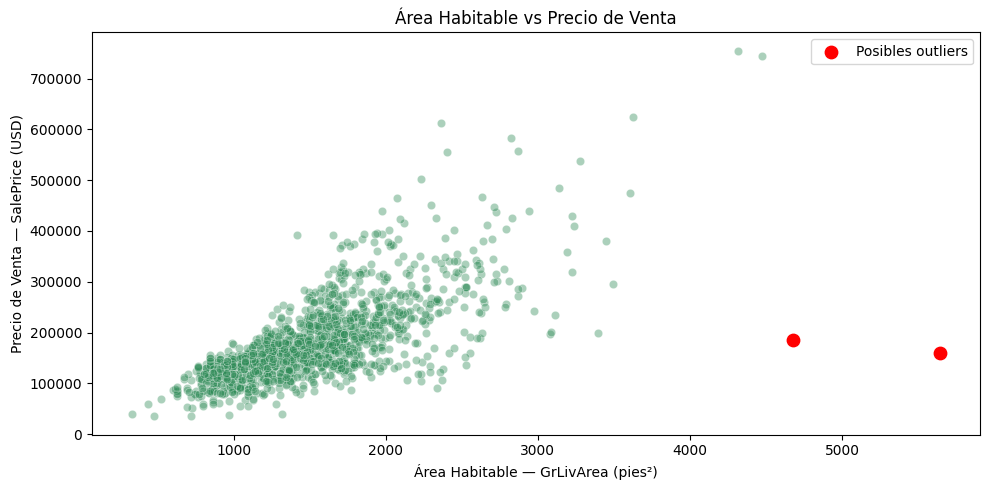

Correlación GrLivArea ↔ SalePrice: 0.7086
Nota: los 2 puntos rojos son outliers conocidos del dataset (ventas atípicas).


In [206]:
plt.figure(figsize=(10, 5))
sns.scatterplot(x=df['GrLivArea'], y=df['SalePrice'], alpha=0.4, color='seagreen')
plt.title('Área Habitable vs Precio de Venta')
plt.xlabel('Área Habitable — GrLivArea (pies²)')
plt.ylabel('Precio de Venta — SalePrice (USD)')

# Marcar los dos outliers clásicos de este dataset (muy grande + precio bajo)
outliers = df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)]
plt.scatter(outliers['GrLivArea'], outliers['SalePrice'], color='red', s=80, zorder=5, label='Posibles outliers')
plt.legend()
plt.tight_layout()
plt.savefig('visualization/scatter_livarea.png', dpi=100)
plt.show()
plt.close()

print("Correlación GrLivArea ↔ SalePrice:", round(df['GrLivArea'].corr(df['SalePrice']), 4))
print(f"Nota: los {outliers['SalePrice'].size} puntos rojos son outliers conocidos del dataset (ventas atípicas).")

### Boxplot: Calidad General vs Precio
- OverallQual es una variable ordinal (escala 1-10) que califica la calidad de los materiales y acabados de la vivienda. Es la variable con mayor correlación con SalePrice (r=0.79).
- Un boxplot muestra cómo varía la distribución del precio en cada nivel de calidad, revelando medianas, rangos intercuartílicos y outliers por categoría.

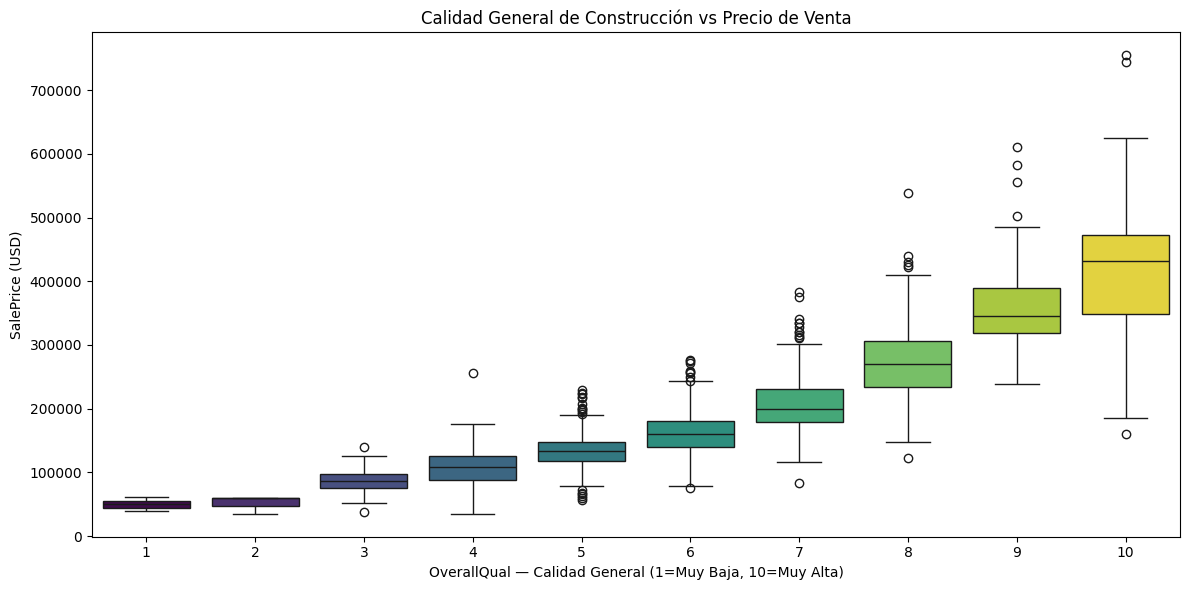

Correlación OverallQual ↔ SalePrice: 0.791
--> A mayor calidad, mayor precio y mayor varianza (los rangos se amplían en niveles altos).


In [207]:
plt.figure(figsize=(12, 6))
sns.boxplot(
    x=df['OverallQual'],
    y=df['SalePrice'],
    hue=df['OverallQual'],
    palette='viridis',
    legend=False
)
plt.title('Calidad General de Construcción vs Precio de Venta')
plt.xlabel('OverallQual — Calidad General (1=Muy Baja, 10=Muy Alta)')
plt.ylabel('SalePrice (USD)')
plt.tight_layout()
plt.savefig('visualization/boxplot_quality.png', dpi=100)
plt.show()
plt.close()

print("Correlación OverallQual ↔ SalePrice:", round(df['OverallQual'].corr(df['SalePrice']), 4))
print("--> A mayor calidad, mayor precio y mayor varianza (los rangos se amplían en niveles altos).")

### Análisis de Variables y Decisiones de Preprocesamiento

A partir del EDA, respondemos las preguntas clave del ejercicio:

#### ¿Hay variables con valores faltantes?
**Sí.** Hay 19 columnas con nulos. Las más críticas:
- `PoolQC` (99.5% nulos), `MiscFeature` (96.3%), `Alley` (93.8%), `Fence` (80.8%) — en estos casos el valor nulo **tiene significado**: la propiedad simplemente no tiene esa característica.
- `LotFrontage` (17.7%), `GarageYrBlt`, `GarageType`, etc. — nulos genuinamente faltantes.

**Estrategia**: Eliminar columnas con >40% de nulos, e imputar el resto con mediana (numéricas) o moda (categóricas).

#### ¿Hay variables categóricas a transformar?
**Sí.** 43 columnas son de tipo `str`/`object` (Neighborhood, SaleType, KitchenQual, etc.). Se convierten a numéricas mediante **One-Hot Encoding**, que crea una columna binaria por cada categoría posible y evita imponer un orden artificial.

#### ¿Hay variables con distribución sesgada u outliers?
**Sí.** `SalePrice` tiene un skewness de ~1.88 (sesgo positivo marcado). Varias variables de área también están sesgadas. Los modelos de árbol son robustos ante esto.

---

#### Elección del Modelo

| Criterio | Regresión Lineal | Random Forest | Gradient Boosting |
|----------|-----------------|---------------|-------------------|
| Relaciones no lineales | ❌ No captura | ✅ Captura | ✅ Captura |
| Outliers en target | ❌ Sensible | ✅ Robusto | ✅ Robusto |
| Multicolinealidad | ❌ Problemática | ✅ La maneja | ✅ La maneja |

#### ¿Por qué se descarta Regresión Lineal?

Los tres problemas anteriores se acumulan en este dataset concreto:
1. **Relaciones no lineales confirmadas** — el scatter plot `GrLivArea` vs `SalePrice` y el boxplot `OverallQual` vs `SalePrice` muestran patrones claramente no lineales que la regresión lineal no puede capturar sin ingeniería de features manual.
2. **Target sesgado y con outliers** — SalePrice tiene skewness > 1 y colas largas. La regresión lineal elevaría el error al cuadrado, dando un peso desproporcionado a las casas más caras y distorsionando los coeficientes globalmente.
3. **Multicolinealidad severa** — variables como `GrLivArea`, `TotalBsmtSF`, `1stFlrSF` y `TotRmsAbvGrd` miden dimensiones solapadas de la misma casa. Con ~200 features tras el One-Hot Encoding, la matriz de diseño es casi singular, lo que hace los coeficientes inestables sin regularización agresiva (Ridge/Lasso).


Los tres problemas juntos hacen que la regresión lineal requiera un trabajo de preprocesamiento adicional considerable (regularización, transformación de features, tratamiento de outliers) que los modelos de árboles gestionan de forma nativa.

---

#### Modelos seleccionados para comparación

Se entrenan y comparan los siguientes cinco modelos, todos evaluados con GridSearchCV (excepto el base):

| Modelo | Descripción | Rol |
|--------|-------------|-----|
| **Random Forest (base)** | 100 árboles, hiperparámetros por defecto | Línea base rápida |
| **Random Forest + GS** | Random Forest con búsqueda de hiperparámetros | Mejor RF posible |
| **Gradient Boosting + GS** | Árboles secuenciales, corrección de errores residuales | Alta precisión, más lento |
| **XGBoost + GS** | Implementación optimizada de Gradient Boosting con regularización L1/L2 nativa, interesante en datasets con muchos features como este| Estado del arte en tabular data |
| **HistGradientBoosting + GS** | Variante basada en histogramas, soporta NaN nativamente, muy rápido | Máxima eficiencia |

**Decisión final**: el modelo a exportar y desplegar se elige automáticamente como el de mayor `R²_cv` (validación cruzada en log-space), que es la métrica más robusta para comparar generalización. El resultado concreto depende de la ejecución y de la rigurosidad de los hiperparámetros, pero la competición esperada es entre **XGBoost + GS** e **HistGradientBoosting + GS**, que sistemáticamente superan a RF y GB clásico en datasets tabulares con esta estructura.

In [ ]:
# Eliminar columnas con >40% de nulos (imputación sería poco fiable)
umbral_nulos = len(df) * 0.4
df_cleaned = df.dropna(thresh=len(df) - umbral_nulos, axis=1).copy()
columnas_eliminadas = set(df.columns) - set(df_cleaned.columns)
print(f"Columnas eliminadas por exceso de nulos (>40%): {sorted(columnas_eliminadas)}")

# Eliminar 'Id': identificador secuencial sin valor predictivo
if 'Id' in df_cleaned.columns:
    df_cleaned.drop('Id', axis=1, inplace=True)

# Separar features (X) y variable objetivo (y)
X = df_cleaned.drop('SalePrice', axis=1)
y = df_cleaned['SalePrice']

# --- Corrección de heterocedasticidad: transformación logarítmica del target ---
# El análisis de distribución (sección anterior) confirmó dos problemas en SalePrice:
#   1. Skewness > 1 --> distribución sesgada a la derecha (cola de casas muy caras)
#   2. Heterocedasticidad: La varianza del error no es constante y puede crecer (o cambiar) con X de forma no lineal --> los errores crecerían con el precio
# Si entrenamos sobre USD brutos, el modelo "acepta" errores grandes en casas caras,
# ya que R² no penaliza proporcionalmente en los extremos altos de la distribución.
#
# Solución: entrenar sobre log1p(SalePrice) = log(SalePrice + 1).
# - Convierte errores absolutos en errores relativos --> homogeneiza los residuos
# - Aplana la distribución sesgada --> la escala del target es más uniforme
# - La inversa exacta es np.expm1(), que se aplica al evaluar para reportar en USD reales
print(f"Skewness SalePrice original : {y.skew():.4f}")
y = np.log1p(y)
print(f"Skewness log(SalePrice+1)   : {y.skew():.4f}  ← distribución más simétrica")

# Identificar tipos de columnas para aplicar transformaciones distintas
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f"\nDimensiones tras limpieza: {df_cleaned.shape}")
print(f"Variables numéricas  : {len(numeric_features)}")
print(f"Variables categóricas: {len(categorical_features)}")
print(f"Total features usadas: {len(numeric_features) + len(categorical_features)}")

Columnas eliminadas por exceso de nulos (>40%): ['Alley', 'Fence', 'FireplaceQu', 'MiscFeature', 'PoolQC']
Skewness SalePrice original : 1.8829
Skewness log(SalePrice+1)   : 0.1213  ← distribución más simétrica

Dimensiones tras limpieza: (1460, 75)
Variables numéricas  : 36
Variables categóricas: 38
Total features usadas: 74


/tmp/ipykernel_26899/3897346949.py:32: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()


#### ¿Por qué entrenar sobre log(SalePrice) y no sobre USD directos?

El EDA confirmó **skewness > 1** en SalePrice. Entrenar sobre el precio en bruto implica que los modelos heredan ese desequilibrio:

| Problema | Efecto sin log | Efecto con log |
|---|---|---|
| Sesgo positivo del target | Escala desigual --> errores grandes en colas | Distribución más simétrica |
| Heterocedasticidad Var(ε\|X) ≠ const. | Errores crecen con el precio | Residuos más homogéneos |
| Métrica R² | No penaliza errores grandes en casas caras | R² en log ≈ penalización relativa uniforme |
| Error absoluto 20k en casa 100k vs. 500k | Tratado igual | Ponderado por escala de precio |

**Flujo resultante:**
1. Entrenar: `model.fit(X_train, log1p(y_train))`
2. Predecir en log-space: `y_pred_log = model.predict(X_test)`
3. Invertir antes de evaluar: `y_pred_usd = np.expm1(y_pred_log)`
4. Métricas MAE / RMSE / MAPE se reportan en **USD reales**

In [209]:
# Usamos sklearn Pipeline para encadenar pasos de transformación de forma reproducible.
# La ventaja del Pipeline es que aplica el mismo preprocesamiento tanto al
# conjunto de entrenamiento como al de test, evitando data leakage.

# Transformador para variables NUMÉRICAS:
numeric_transformer = Pipeline(steps=[
    # SimpleImputer rellena los NaN con la MEDIANA de cada columna del train set.
    # Elegimos mediana (no media) porque es robusta ante outliers: un LotFrontage extremo
    # no distorsionará el valor de relleno.
    ('imputer', SimpleImputer(strategy='median')),
    # StandardScaler normaliza cada feature a media=0 y desviación=1.
    # Aunque Random Forest no lo necesita (los árboles son invariantes a escala),
    # lo incluimos para que el pipeline sirva también para modelos sensibles a escala
    # como el MLP o futuros modelos de regresión lineal.
    ('scaler', StandardScaler())
])

# Pipeline categórico: moda para nulos + OHE (handle_unknown ignora categorías no vistas en producción)
categorical_transformer = Pipeline(steps=[
    # Imputamos categóricas con la MODA (valor más frecuente) de cada columna.
    # Es la única opción con sentido semántico para variables nominales.
    ('imputer', SimpleImputer(strategy='most_frequent')),
    # OneHotEncoder transforma cada categoría en una columna binaria (0/1).
    # handle_unknown='ignore' descarta categorías no vistas durante el entrenamiento,
    # previniendo errores en producción cuando llegan datos nuevos.
    # sparse_output=False devuelve un array denso (compatible con todos los estimadores).
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer aplica transformadores distintos según el tipo de columna.
# Permite mantener un solo objeto que procesa todo el dataset de forma coordinada.
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

# --- División Train/Test ---
# Usamos 80% para entrenar y 20% para evaluar.
# random_state=42 garantiza reproducibilidad (siempre la misma partición).
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de evaluación  : {X_test.shape[0]}")
print("Pipeline de preprocesamiento construido.")

Muestras de entrenamiento: 1168
Muestras de evaluación  : 292
Pipeline de preprocesamiento construido.


---
## EJERCICIO 2: Modelado y Evaluación

### Modelo Base: Random Forest Regressor

**¿Por qué Random Forest?**
- Es un ensamble de árboles de decisión entrenados sobre subconjuntos aleatorios del dataset (*bagging*).
- Cada árbol aprende una parte distinta del espacio de features, y el resultado final es el **promedio** de todas las predicciones individuales.
- Esto reduce el sobreajuste (overfitting) que sufre un árbol individual.
- No asume linealidad ni distribución normal en los datos.
- Maneja de forma nativa variables mixtas (numéricas + categóricas ya codificadas).

**Hiperparámetros iniciales:**
- `n_estimators=100`: 100 árboles en el bosque (balance velocidad/precisión)
- `random_state=42`: reproducibilidad

In [210]:
# --- Construcción del Pipeline Completo: Preprocesamiento + Modelo ---
# Al encadenar el preprocesador y el regresor en un solo Pipeline:
# 1. fit() aprende las transformaciones y el modelo en un solo paso
# 2. predict() aplica exactamente las mismas transformaciones a datos nuevos
# 3. GridSearchCV puede buscar hiperparámetros tanto del preprocesamiento como del modelo (luego lo veremos)
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
    # n_jobs=-1 usa todos los núcleos del CPU disponibles para entrenar en paralelo
])
print("Pipeline Random Forest creado.")

Pipeline Random Forest creado.


In [211]:
# --- Entrenamiento del Modelo ---
# fit() ejecuta en secuencia:
#   1. Preprocesamiento: imputa nulos, escala numéricas, codifica categóricas (solo con train data)
#   2. Entrenamiento: construye los 100 árboles del Random Forest
# Medir el tiempo nos da información sobre la viabilidad de reentrenar el modelo en producción.
print("Entrenando Random Forest (modelo base)...")
start_time = time.time()
rf_pipeline.fit(X_train, y_train)
rf_time = time.time() - start_time

Entrenando Random Forest (modelo base)...


In [212]:
# --- Evaluación del Modelo ---
# El modelo entrenó sobre log(SalePrice+1), así que predice en esa misma escala.
# Aplicamos expm1 (inversa de log1p) para convertir a USD reales antes de calcular métricas,
# de modo que MAE, RMSE y MAPE son directamente interpretables en dólares / porcentaje.

y_pred_log  = rf_pipeline.predict(X_test)
y_pred      = np.expm1(y_pred_log)   # USD reales
y_test_real = np.expm1(y_test)       # USD reales (y_test está en escala log)

mse   = mean_squared_error(y_test_real, y_pred)
rmse  = np.sqrt(mse)
mae   = mean_absolute_error(y_test_real, y_pred)
r2_rf = r2_score(y_test_real, y_pred)
# MAPE evalúa el error de forma relativa: un error de 20k en casa de 100k (20%) es muy distinto
# al mismo error en una casa de 500k (4%). R² y MAE no capturan esta asimetría; MAPE sí.
mape_rf = np.mean(np.abs((y_test_real - y_pred) / y_test_real))

print("=" * 56)
print("  MÉTRICAS — Random Forest Base (USD reales)")
print("=" * 56)
print(f"  MSE  (Error Cuadrático Medio)   : ${mse:>15,.2f}")
print(f"  RMSE (Raíz del MSE)             : ${rmse:>15,.2f}")
print(f"  MAE  (Error Absoluto Medio)     : ${mae:>15,.2f}")
print(f"  MAPE (Error Relativo Medio)     : {mape_rf*100:>17.2f}%")
print(f"  R²   (Coeficiente Determinación): {r2_rf:>18.4f}")
print("=" * 56)
print(f"\nInterpretación:")
print(f"  --> En promedio, el modelo se equivoca ~${mae:,.0f} por vivienda (MAE).")
print(f"  --> El error relativo promedio es {mape_rf*100:.1f}% del precio real (MAPE).")
print(f"  --> El R²={r2_rf:.4f} indica que el modelo explica el {r2_rf*100:.1f}% de la varianza del precio.")

# --- Validación Cruzada (k-fold) ---
# cross_val_score opera en espacio log (y transformado); el R² se calcula en esa escala.
# Es la métrica correcta para seleccionar hiperparámetros porque el modelo optimiza en log-space.
# Nota: el R²_cv aquí no es directamente comparable con el R² calculado en USD, pero
# sirve para comparar modelos entre sí de forma consistente.
print("\nValidación Cruzada (cv=5, métrica R² en escala log)...")
cv_scores = cross_val_score(rf_pipeline, X, y, cv=5, scoring='r2', n_jobs=-1)
r2_rf_cv = cv_scores.mean()
r2_cv_std = cv_scores.std()

print(f"  R² por fold: {[round(s, 4) for s in cv_scores]}")
print(f"  R² Medio   : {r2_rf_cv:.4f} ± {r2_cv_std:.4f}")
print(f"  --> Baja desviación estándar indica que el modelo es estable entre particiones.")

  MÉTRICAS — Random Forest Base (USD reales)
  MSE  (Error Cuadrático Medio)   : $ 840,731,296.91
  RMSE (Raíz del MSE)             : $      28,995.37
  MAE  (Error Absoluto Medio)     : $      17,363.12
  MAPE (Error Relativo Medio)     :             10.24%
  R²   (Coeficiente Determinación):             0.8904

Interpretación:
  --> En promedio, el modelo se equivoca ~$17,363 por vivienda (MAE).
  --> El error relativo promedio es 10.2% del precio real (MAPE).
  --> El R²=0.8904 indica que el modelo explica el 89.0% de la varianza del precio.

Validación Cruzada (cv=5, métrica R² en escala log)...
  R² por fold: [0.8716, 0.8668, 0.8782, 0.8873, 0.8523]
  R² Medio   : 0.8712 ± 0.0117
  --> Baja desviación estándar indica que el modelo es estable entre particiones.


In [213]:
params_rf = rf_pipeline.named_steps['regressor'].get_params()
params_rf = {
    k: v for k, v in params_rf.items()
    if k in ['n_estimators', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'max_features']
}
print(f"\nHiperparámetros actuales del Random Forest:")
for param, value in params_rf.items():
    print(f"  {param}: {value}")


Hiperparámetros actuales del Random Forest:
  max_depth: None
  max_features: 1.0
  min_samples_leaf: 1
  min_samples_split: 2
  n_estimators: 100


### Análisis de Errores (Residuos)

Los residuos son la diferencia entre el valor real y el predicho: `e = y_real − y_pred`.

Dado que el modelo entrenó sobre `log(SalePrice+1)`, las predicciones se invierten con `np.expm1` antes de calcular los residuos, de modo que se expresan en **USD reales** y son directamente interpretables.

Un modelo ideal tendría residuos:
  - Distribuidos simétricamente alrededor de 0 (sin sesgo sistemático)
  - Con varianza constante para todos los rangos de precio (**homocedasticidad**)
  - Sin patrones (si hay patrones, el modelo no captura alguna relación)

La transformación logarítmica del target debe reducir el patrón de abanico (heterocedasticidad) que aparecería al entrenar sobre USD brutos.

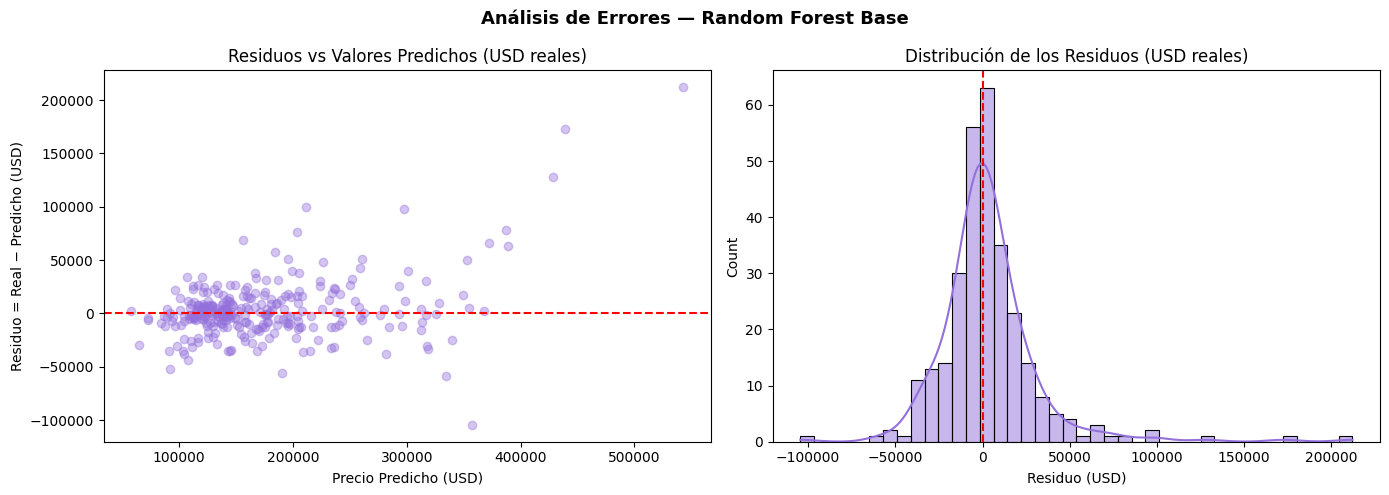

Residuo medio (sesgo): $3,323.25  (debería ser ~0)
Std de residuos      : $28,853.74
Residuo máximo (positivo): $212,048.36
Residuo mínimo (negativo): $-104,455.54
MAPE                 : 10.24%  (error relativo promedio)


In [214]:
# y_pred e y_test_real ya están en USD reales (expm1 aplicado en la celda de evaluación anterior)
residuos = y_test_real - y_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Residuos vs Valores Predichos
# Gracias a la transformación log del target, el patrón de abanico (heterocedasticidad)
# debería ser menos pronunciado que entrenando sobre USD brutos.
# Si aún se observa abanico leve, es esperable: los árboles tienen resolución discreta
# en precios muy altos donde los datos son escasos.
axes[0].scatter(y_pred, residuos, alpha=0.4, color='mediumpurple')
axes[0].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residuos vs Valores Predichos (USD reales)')
axes[0].set_xlabel('Precio Predicho (USD)')
axes[0].set_ylabel('Residuo = Real − Predicho (USD)')

# Gráfico 2: Distribución de los residuos
# Una distribución aproximadamente normal centrada en 0 es ideal.
sns.histplot(residuos, bins=40, kde=True, ax=axes[1], color='mediumpurple')
axes[1].axvline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Distribución de los Residuos (USD reales)')
axes[1].set_xlabel('Residuo (USD)')

plt.suptitle('Análisis de Errores — Random Forest Base', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('visualization/residuos_rf.png', dpi=100)
plt.show()
plt.close()

print(f"Residuo medio (sesgo): ${residuos.mean():,.2f}  (debería ser ~0)")
print(f"Std de residuos      : ${residuos.std():,.2f}")
print(f"Residuo máximo (positivo): ${residuos.max():,.2f}")
print(f"Residuo mínimo (negativo): ${residuos.min():,.2f}")
mape_residuos = np.mean(np.abs(residuos / y_test_real))
print(f"MAPE                 : {mape_residuos*100:.2f}%  (error relativo promedio)")

---
## EJERCICIO 3: Optimización y Despliegue

### Ajuste de Hiperparámetros con GridSearchCV

El modelo base usa valores por defecto. **GridSearchCV** prueba sistemáticamente combinaciones de hiperparámetros y elige la que mejor R² obtiene en validación cruzada.

**Hiperparámetros a optimizar:**
- `n_estimators`: número de árboles. Más árboles --> menor varianza, pero más tiempo de cómputo.
- `max_depth`: profundidad máxima de cada árbol. Árboles muy profundos --> overfitting; muy superficiales --> underfitting.
- `learning_rate`: optimizar tasa de aprendizaje al valor que de mejores resultados

In [ ]:
def grid_search_pipeline(estimator, param_grid, X_train, y_train, X_test, y_test, cv=3):
    # y_train e y_test están en escala log(SalePrice+1).
    # GridSearchCV optimiza R² en ese espacio (correcto: el modelo vive en log).
    # Las métricas de reporte (MAE, RMSE, MAPE) se calculan en USD reales (expm1).

    n_combinations = reduce(operator.mul, [len(v) for v in param_grid.values()], 1)

    print(f"Combinaciones a probar: {n_combinations} × {cv} folds CV")
    print("Iniciando búsqueda de hiperparámetros...\n")

    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', estimator)
    ])

    start = time.time()

    grid_search = GridSearchCV(
        pipeline,
        param_grid,
        cv=cv,
        scoring='r2',
        n_jobs=-1,
        verbose=1
    )

    grid_search.fit(X_train, y_train)
    exec_time = time.time() - start

    best = grid_search.best_estimator_

    # Predicciones en escala log --> invertir a USD reales para métricas interpretables
    y_pred_log  = best.predict(X_test)
    y_pred      = np.expm1(y_pred_log)
    y_test_real = np.expm1(y_test)

    r2        = r2_score(y_test_real, y_pred)
    r2_cv     = grid_search.best_score_   # R² en log-space (usado para selección del modelo)
    r2_cv_std = grid_search.cv_results_['std_test_score'][grid_search.best_index_]
    mae       = mean_absolute_error(y_test_real, y_pred)
    rmse      = np.sqrt(mean_squared_error(y_test_real, y_pred))
    mape      = np.mean(np.abs((y_test_real - y_pred) / y_test_real))

    best_params = grid_search.best_params_
    print(f"\nMejores parámetros: {grid_search.best_params_}")
    print(f"R² en CV (escala log): {r2_cv:.4f}")

    print("\nResultados en Test (USD reales):")
    print(f"R²  : {r2:.4f}")
    print(f"MAE : ${mae:,.2f}")
    print(f"RMSE: ${rmse:,.2f}")
    print(f"MAPE: {mape*100:.2f}%")

    print(f"\nTiempo total: {exec_time:.1f} s")

    return best, r2, r2_cv, r2_cv_std, mae, rmse, mape, best_params, exec_time

In [ ]:
rf_param_grid = {
    'regressor__n_estimators': [200, 300, 500],
    'regressor__max_depth': [None, 10, 20, 30],
    'regressor__min_samples_split': [2, 5, 10],
    'regressor__min_samples_leaf': [1, 2, 4],
    'regressor__max_features': ['sqrt', 'log2', 0.7],
}

# Random Forest suele ser más rápido que Gradient Boosting clásico gracias a su naturaleza paralelizable y a que cada árbol se construye de forma independiente.
# Claves diferenciales de RF:
# - Naturaleza paralelizable: cada árbol se entrena de forma independiente, lo que permite utilizar múltiples núcleos de CPU.
# - Menor riesgo de overfitting: el promedio de múltiples árboles reduce la varianza del modelo.
best_rf_gs, r2_rf_gs, r2_cv_rf_gs, r2_cv_std_rf_gs, mae_rf_gs, rmse_rf_gs, mape_rf_gs, best_params_rf_gs, rf_gs_time = grid_search_pipeline(
    RandomForestRegressor(),
    rf_param_grid,
    X_train,
    y_train,
    X_test,
    y_test,
    cv=3
)

gb_param_grid = {
    'regressor__n_estimators': [100, 200, 300],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [1, 2, 3, 4],
    'regressor__subsample': [0.6, 0.8, 1.0],
    'regressor__min_samples_split': [2, 5, 10],
}

# Gradient Boosting es un modelo secuencial que construye árboles de forma iterativa, corrigiendo los errores del anterior. Esto lo hace más lento que Random Forest, especialmente con muchos árboles o profundidad.
# Claves diferenciales de GB:
# - Modelo secuencial: cada árbol se construye corrigiendo los errores del anterior, lo que puede mejorar la precisión pero aumenta el tiempo de entrenamiento.
# - Mayor riesgo de overfitting: si no se regulan adecuadamente los hiperparámetros (como learning_rate o max_depth), el modelo puede ajustarse demasiado a los datos de entrenamiento.
best_gb_gs, r2_gb_gs, r2_cv_gb_gs, r2_cv_std_gb_gs, mae_gb_gs, rmse_gb_gs, mape_gb_gs, best_params_gb_gs, gb_gs_time = grid_search_pipeline(
    GradientBoostingRegressor(),
    gb_param_grid,
    X_train,
    y_train,
    X_test,
    y_test,
    cv=3
)

Combinaciones a probar: 324 × 3 folds CV
Iniciando búsqueda de hiperparámetros...

Fitting 3 folds for each of 324 candidates, totalling 972 fits

Mejores parámetros: {'regressor__max_depth': 20, 'regressor__max_features': 0.7, 'regressor__min_samples_leaf': 1, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 200}
R² en CV (escala log): 0.8727

Resultados en Test (USD reales):
R²  : 0.8895
MAE : $16,833.86
RMSE: $29,118.09
MAPE: 9.91%

Tiempo total: 39.2 s
Combinaciones a probar: 324 × 3 folds CV
Iniciando búsqueda de hiperparámetros...

Fitting 3 folds for each of 324 candidates, totalling 972 fits

Mejores parámetros: {'regressor__learning_rate': 0.1, 'regressor__max_depth': 3, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 300, 'regressor__subsample': 0.8}
R² en CV (escala log): 0.8999

Resultados en Test (USD reales):
R²  : 0.9101
MAE : $15,777.85
RMSE: $26,265.03
MAPE: 9.00%

Tiempo total: 24.6 s


In [ ]:
xgb_param_grid = {
    'regressor__n_estimators': [300, 500],
    'regressor__learning_rate': [0.01, 0.05, 0.1],
    'regressor__max_depth': [3, 5, 7],
    'regressor__subsample': [0.7, 0.9, 1.0],
    'regressor__colsample_bytree': [0.7, 0.9, 1.0],
}

# XGBoost suele ser más rápido que Gradient Boosting clásico gracias a su implementación optimizada y paralelización.
# Claves diferenciales de XGBoost:
# - Regularización L1/L2 integrada --> mejor manejo de overfitting en datasets con
#   muchas features (como este con 80+ columnas tras OHE).
# - Implementación optimizada en C++ con paralelización --> tiempos de entrenamiento más rápidos
#  incluso con hiperparámetros más agresivos (más árboles, mayor profundidad).
best_xgb_gs, r2_xgb_gs, r2_cv_xgb_gs, r2_cv_std_xgb_gs, mae_xgb_gs, rmse_xgb_gs, mape_xgb_gs, best_params_xgb_gs, xgb_gs_time = grid_search_pipeline(
    XGBRegressor(objective='reg:squarederror', random_state=42),
    xgb_param_grid,
    X_train,
    y_train,
    X_test,
    y_test,
    cv=3
)

hgb_param_grid = {
    'regressor__learning_rate': [0.03, 0.05, 0.1],
    'regressor__max_depth': [None, 5, 10],
    'regressor__max_iter': [200, 400, 600],
    'regressor__min_samples_leaf': [10, 20, 30],
}

# HistGradientBoostingRegressor es una implementación de boosting basada en histogramas que suele ser más rápida que GradientBoostingRegressor clásico, especialmente en datasets grandes o con muchas features.
# Claves diferenciales de HGB:
# - Basado en histogramas: agrupa valores continuos en bins, lo que reduce
#   la complejidad computacional y acelera el entrenamiento.
# - Soporta nativamente variables categóricas (aunque aquí usamos OHE para mantener consistencia con los otros modelos).

best_hgb_gs, r2_hgb_gs, r2_cv_hgb_gs, r2_cv_std_hgb_gs, mae_hgb_gs, rmse_hgb_gs, mape_hgb_gs, best_params_hgb_gs, hgb_gs_time = grid_search_pipeline(
    HistGradientBoostingRegressor(random_state=42),
    hgb_param_grid,
    X_train,
    y_train,
    X_test,
    y_test,
    cv=3
)

Combinaciones a probar: 162 × 3 folds CV
Iniciando búsqueda de hiperparámetros...

Fitting 3 folds for each of 162 candidates, totalling 486 fits

Mejores parámetros: {'regressor__colsample_bytree': 0.7, 'regressor__learning_rate': 0.05, 'regressor__max_depth': 3, 'regressor__n_estimators': 500, 'regressor__subsample': 0.9}
R² en CV (escala log): 0.9023

Resultados en Test (USD reales):
R²  : 0.9121
MAE : $15,379.95
RMSE: $25,962.57
MAPE: 8.84%

Tiempo total: 19.0 s
Combinaciones a probar: 81 × 3 folds CV
Iniciando búsqueda de hiperparámetros...

Fitting 3 folds for each of 81 candidates, totalling 243 fits

Mejores parámetros: {'regressor__learning_rate': 0.03, 'regressor__max_depth': 5, 'regressor__max_iter': 600, 'regressor__min_samples_leaf': 10}
R² en CV (escala log): 0.8903

Resultados en Test (USD reales):
R²  : 0.8979
MAE : $16,486.12
RMSE: $27,986.67
MAPE: 9.62%

Tiempo total: 130.9 s


### Comparación de Modelos

**Métrica de selección del modelo final: `R²_cv` (escala log)**

R² es siempre un número adimensional (0–1) — nunca tiene unidades de USD. La distinción "escala log vs USD" indica sobre qué residuos se calcula:

- **R²_cv (log-space):** `1 − Σ(log(yᵢ) − log(ŷᵢ))² / Σ(log(yᵢ) − media)²` --> varianza explicada del precio logarítmico.
- **R² (test set, USD):** `1 − Σ(yᵢ − ŷᵢ)² / Σ(yᵢ − media)²` --> varianza explicada del precio en USD. Ambos son dimensionless y dan números distintos porque `expm1` es no lineal.

| Métrica | Pros | Contras | Uso |
|---|---|---|---|
| R² (test set) | Varianza explicada en USD-space | Una sola partición --> alta varianza de la estimación | Reporte |
| **R²_cv (log-space)** | **k-fold --> robusto**, todos los modelos optimizaron en este espacio | Menos intuitivo para stakeholders no técnicos | **Selección** |
| MAPE (test set) | Directo: "el modelo se equivoca X% del precio real" | Una sola partición --> alta varianza | Reporte / negocio |

`R²_cv` se elige como criterio de selección porque: (1) se calcula sobre múltiples particiones — no una sola —, lo que reduce la varianza de la estimación; y (2) es el espacio en el que todos los modelos optimizaron, por lo que la comparación es directamente consistente. El `MAPE` en test complementa la decisión desde la perspectiva de negocio.

,R²,R²_cv,R²_cv_std,MAE,RMSE,MAPE (%),Tiempo (s),Params
RF Base,0.890400,0.871200,0.011700,17363.000000,28995.000000,10.240000,0.200000,"max_depth=None, max_features=1.0, min_samples_leaf=1, min_samples_split=2, n_estimators=100"
RF + GS,0.889500,0.872700,0.015200,16834.000000,29118.000000,9.910000,39.200000,"max_depth=20, max_features=0.7, min_samples_leaf=1, min_samples_split=2, n_estimators=200"
GB + GS,0.910100,0.899900,0.010900,15778.000000,26265.000000,9.000000,24.600000,"learning_rate=0.1, max_depth=3, min_samples_split=2, n_estimators=300, subsample=0.8"
XGB + GS,0.912100,0.902300,0.011300,15380.000000,25963.000000,8.840000,19.000000,"colsample_bytree=0.7, learning_rate=0.05, max_depth=3, n_estimators=500, subsample=0.9"
HGB + GS,0.897900,0.890300,0.010000,16486.000000,27987.000000,9.620000,130.900000,"learning_rate=0.03, max_depth=5, max_iter=600, min_samples_leaf=10"


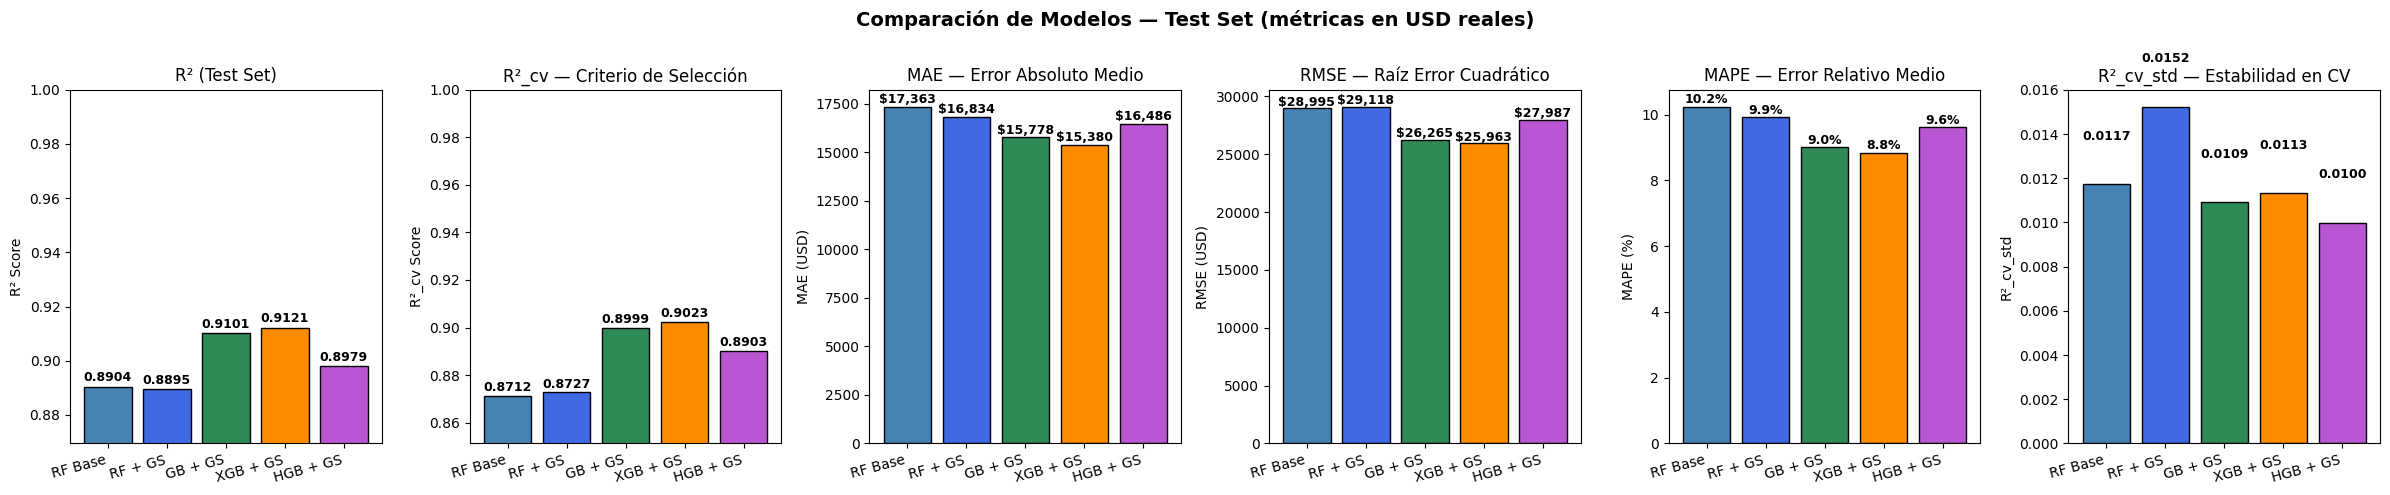


--> Modelo seleccionado : 'XGB + GS'
    R²_cv               : 0.9023
    MAPE (test)         : 8.84%
    Regresor            : XGBRegressor


In [218]:
resultados = {
    'RF Base':{
        'R²': r2_rf,
        'R²_cv': r2_rf_cv,
        'R²_cv_std': r2_cv_std,
        'MAE': mae,
        'RMSE': rmse,
        'MAPE (%)': round(mape_rf * 100, 2),
        'Params': params_rf,
        'Tiempo (s)': rf_time
    },
    'RF + GS':{
        'R²': r2_rf_gs,
        'R²_cv': r2_cv_rf_gs,
        'R²_cv_std': r2_cv_std_rf_gs,
        'MAE': mae_rf_gs,
        'RMSE': rmse_rf_gs,
        'MAPE (%)': round(mape_rf_gs * 100, 2),
        'Params': best_params_rf_gs,
        'Tiempo (s)': rf_gs_time
    },
    'GB + GS':{
        'R²': r2_gb_gs,
        'R²_cv': r2_cv_gb_gs,
        'R²_cv_std': r2_cv_std_gb_gs,
        'MAE': mae_gb_gs,
        'RMSE': rmse_gb_gs,
        'MAPE (%)': round(mape_gb_gs * 100, 2),
        'Params': best_params_gb_gs,
        'Tiempo (s)': gb_gs_time
    },
    'XGB + GS':{
        'R²': r2_xgb_gs,
        'R²_cv': r2_cv_xgb_gs,
        'R²_cv_std': r2_cv_std_xgb_gs,
        'MAE': mae_xgb_gs,
        'RMSE': rmse_xgb_gs,
        'MAPE (%)': round(mape_xgb_gs * 100, 2),
        'Params': best_params_xgb_gs,
        'Tiempo (s)': xgb_gs_time
    },
    'HGB + GS':{
        'R²': r2_hgb_gs,
        'R²_cv': r2_cv_hgb_gs,
        'R²_cv_std': r2_cv_std_hgb_gs,
        'MAE': mae_hgb_gs,
        'RMSE': rmse_hgb_gs,
        'MAPE (%)': round(mape_hgb_gs * 100, 2),
        'Params': best_params_hgb_gs,
        'Tiempo (s)': hgb_gs_time
    }
}

def format_params(params: dict) -> str:
    clean_items = []

    for k, v in params.items():

        k = k.replace('regressor__', '')

        if isinstance(v, float):
            v = round(v, 4)

        clean_items.append((k, v))

    # ordenar por clave
    clean_items.sort(key=lambda x: x[0])

    return ", ".join([f"{k}={v}" for k, v in clean_items])


tabla = pd.DataFrame(resultados).T

tabla = tabla[['R²', 'R²_cv', 'R²_cv_std', 'MAE', 'RMSE', 'MAPE (%)', 'Tiempo (s)', 'Params']]

# formateo
tabla['R²'] = tabla['R²'].round(4)
tabla['R²_cv'] = tabla['R²_cv'].round(4)
tabla['R²_cv_std'] = tabla['R²_cv_std'].round(4)
tabla['MAE'] = tabla['MAE'].round(0)
tabla['RMSE'] = tabla['RMSE'].round(0)
tabla['MAPE (%)'] = tabla['MAPE (%)'].round(2)
tabla['Tiempo (s)'] = tabla['Tiempo (s)'].round(1)

tabla['Params'] = tabla['Params'].apply(format_params)
styled = tabla.style.set_table_styles([
    {
        'selector': 'th',
        'props': [
            ('text-align', 'left'),
            ('white-space', 'normal')
        ]
    },
    {
        'selector': 'td',
        'props': [
            ('text-align', 'left'),
            ('white-space', 'normal'),
            ('word-break', 'break-word'),
            ('overflow-wrap', 'break-word')
        ]
    },
    {
        'selector': 'table',
        'props': [
            ('width', '100%'),
            ('table-layout', 'fixed')
        ]
    }
])
display(styled)

# Gráfico comparativo
fig, axes = plt.subplots(1, 6, figsize=(24, 5))

nombres = list(resultados.keys())
colores = ['steelblue', 'royalblue', 'seagreen', 'darkorange', 'mediumorchid']

r2_vals        = [resultados[n]['R²']        for n in nombres]
r2_cv_vals     = [resultados[n]['R²_cv']     for n in nombres]
mae_vals       = [resultados[n]['MAE']       for n in nombres]
rmse_vals      = [resultados[n]['RMSE']      for n in nombres]
mape_vals      = [resultados[n]['MAPE (%)']  for n in nombres]
r2_cv_std_vals = [resultados[n]['R²_cv_std'] for n in nombres]

axes[0].bar(nombres, r2_vals, color=colores, edgecolor='black')
axes[0].set_title('R² (Test Set)')
axes[0].set_ylabel('R² Score')
axes[0].set_ylim(min(r2_vals) - 0.02, 1.0)
for i, v in enumerate(r2_vals):
    axes[0].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

axes[1].bar(nombres, r2_cv_vals, color=colores, edgecolor='black')
axes[1].set_title('R²_cv — Criterio de Selección')
axes[1].set_ylabel('R²_cv Score')
axes[1].set_ylim(min(r2_cv_vals) - 0.02, 1.0)
for i, v in enumerate(r2_cv_vals):
    axes[1].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

axes[2].bar(nombres, mae_vals, color=colores, edgecolor='black')
axes[2].set_title('MAE — Error Absoluto Medio')
axes[2].set_ylabel('MAE (USD)')
for i, v in enumerate(mae_vals):
    axes[2].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

axes[3].bar(nombres, rmse_vals, color=colores, edgecolor='black')
axes[3].set_title('RMSE — Raíz Error Cuadrático')
axes[3].set_ylabel('RMSE (USD)')
for i, v in enumerate(rmse_vals):
    axes[3].text(i, v + 200, f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

axes[4].bar(nombres, mape_vals, color=colores, edgecolor='black')
axes[4].set_title('MAPE — Error Relativo Medio')
axes[4].set_ylabel('MAPE (%)')
for i, v in enumerate(mape_vals):
    axes[4].text(i, v + 0.1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

axes[5].bar(nombres, r2_cv_std_vals, color=colores, edgecolor='black')
axes[5].set_title('R²_cv_std — Estabilidad en CV')
axes[5].set_ylabel('R²_cv_std')
for i, v in enumerate(r2_cv_std_vals):
    axes[5].text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9, fontweight='bold')

for ax in axes:
    ax.set_xticks(range(len(nombres)))
    ax.set_xticklabels(nombres, rotation=15, ha='right')

plt.suptitle('Comparación de Modelos — Test Set (métricas en USD reales)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('visualization/comparacion_modelos.png', dpi=100)
plt.show()
plt.close()

# --- Selección del modelo final ---
# Criterio: R²_cv (escala log, k-fold) — ver justificación en la celda anterior.
mejor_modelo_nombre = max(resultados, key=lambda n: resultados[n]['R²_cv'])

# Mapa exhaustivo: cubre los 5 modelos posibles.
# RF Base no tiene GridSearch; los demás son los pipelines devueltos por grid_search_pipeline().
modelo_map = {
    'RF Base':  rf_pipeline,
    'RF + GS':  best_rf_gs,
    'GB + GS':  best_gb_gs,
    'XGB + GS': best_xgb_gs,
    'HGB + GS': best_hgb_gs,
}
modelo_final = modelo_map[mejor_modelo_nombre]

print(f"\n--> Modelo seleccionado : '{mejor_modelo_nombre}'")
print(f"    R²_cv               : {resultados[mejor_modelo_nombre]['R²_cv']:.4f}")
print(f"    MAPE (test)         : {resultados[mejor_modelo_nombre]['MAPE (%)']:.2f}%")
print(f"    Regresor            : {type(modelo_final.named_steps['regressor']).__name__}")

joblib serializa el objeto Pipeline completo (preprocesador + modelo) en un archivo binario.
Esto significa que para predecir basta con pasar los datos crudos sin preprocesar.

In [219]:
os.makedirs('model', exist_ok=True)
ruta_modelo = 'model/modelo_precio_casa.joblib'
joblib.dump(modelo_final, ruta_modelo)

print(f"Modelo guardado en: {ruta_modelo}")
print("Contenido del pipeline exportado:")
for nombre, paso in modelo_final.named_steps.items():
    print(f"  - {nombre}: {type(paso).__name__}")

Modelo guardado en: model/modelo_precio_casa.joblib
Contenido del pipeline exportado:
  - preprocessor: ColumnTransformer
  - regressor: XGBRegressor


### Despliegue como API REST con Flask

El archivo adjunto `app_proyecto_final.py` implementa una API REST con Flask que expone el modelo como servicio web. Esto permite que cualquier aplicación (frontend, app móvil, otro servicio) solicite predicciones enviando los datos de una vivienda en formato JSON.

**Arquitectura del despliegue:**

```
Cliente (JSON)  -->  POST /predict  -->  Flask API  -->  Pipeline.predict()  -->  { "precio_estimado_usd": 215000 }
```

**Endpoints disponibles:**
| Método | Ruta | Descripción |
|--------|------|-------------|
| GET | `/` | Estado del servicio y documentación |
| POST | `/predict` | Recibe datos de una casa, devuelve precio estimado |

**Para ejecutar la API:**
```bash
# 1. Asegurarse de haber ejecutado todas las celdas anteriores (genera el modelo)
# 2. Instalar Flask si no está disponible:
pip install flask
# 3. Ejecutar el servidor:
python app_proyecto_final.py
```


**Ejemplo de uso (curl):**
```bash
curl -X POST http://localhost:5001/predict \
  -H "Content-Type: application/json" \
  -d '{"OverallQual": 7, "GrLivArea": 1500, "GarageCars": 2, "TotalBsmtSF": 900, "YearBuilt": 2000}'
```
> El pipeline serializado con joblib maneja automáticamente el preprocesamiento de los datos de entrada, por lo que la API acepta datos crudos directamente sin necesidad de transformación previa.

> Puede recibir 5 parámetros pese a que espere más columnas, ya que en la API, si no se encuentra esa columna, se pone como NaN, y luego los Imputers del modelo se encargan de rellenar esos valores con la mediana en variables numéricas o el valor más frecuente (moda) en variables categóricas.

---
## Conclusiones

### Resumen del Proceso

| Fase | Decisión | Justificación |
|------|----------|---------------|
| EDA | Análisis de nulos, distribución y correlación | Identificar qué datos necesitan tratamiento antes de modelar |
| Filtrado | Eliminar columnas con >40% nulos + `Id` | Evitar ruido y correlaciones espurias |
| Imputación | Mediana para numéricos, moda para categóricos | Robustez ante outliers / semántica correcta para categorías |
| Encoding | One-Hot Encoding | Convierte categorías sin imponer un orden artificial |
| Modelo base | Random Forest (100 árboles) | Robusto, paralelizable, no asume linealidad |
| Optimización | GridSearchCV (n_estimators, max_depth) | Búsqueda sistemática del mejor balance bias-varianza |
| Comparación | Random Forest vs Gradient Boosting vs XGBoost vs HistGradientBoosting | Gradient Boosting tiende a superar a RF en precisión a costa de tiempo |
| Despliegue | Flask API + joblib | El Pipeline serializado incluye el preprocesamiento, simplificando la API |

### Lecciones Clave

1. **Los modelos de árbol son ideales para este tipo de dataset**: mezcla de variables numéricas y categóricas, distribuciones sesgadas, y relaciones no lineales.
2. **El Pipeline de sklearn es fundamental**: previene *data leakage* (las transformaciones se aprenden solo con datos de entrenamiento) y hace el modelo directamente desplegable.
3. **Gradient Boosting supera a Random Forest en precisión** pero a mayor costo computacional: el boosting secuencial no se puede paralelizar de la misma forma.
4. **El análisis de residuos revela heterocedasticidad**: los errores son mayores para viviendas de precio alto, lo que sugiere que aplicar `log(SalePrice)` como target podría mejorar aún más el modelo.